In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fertilizer_recommendation_dataset.csv to fertilizer_recommendation_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('fertilizer_recommendation_dataset.csv')  # or .xlsx
print(df.head())
print(df.columns)

   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy Soil  rice     Balanced NPK Fertilizer   
4   97.000886  1.782985  Peaty Soil  rice          Organic Fertilizer   

                                              Remark  
0  Enhances organic matter and improves soil stru...  
1  Pro

In [ ]:
print(df.isnull().sum())
print(df.describe())

Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64
       Temperature     Moisture     Rainfall           PH     Nitrogen  \
count  3100.000000  3100.000000  3100.000000  3100.000000  3100.000000   
mean     27.271096     0.600763   111.024949     6.379775    61.278480   
std       9.114450     0.144947    77.151880     0.957103    10.186410   
min       4.011486     0.227436   -85.709593     3.448974    35.527718   
25%      22.408505     0.493595    61.283985     5.860489    54.835715   
50%      26.132938     0.599520    96.485935     6.337308    59.429649   
75%      29.987887     0.708575   147.619401     6.899739    65.792790   
max      56.653592     0.972361   411.955947     9.562341    98.581039   

       Phosphorous    Potassium       Carbon  
count  3100.000000  3100.000000  3100.000000  
mean     69.582850    

In [ ]:
# See first few rows
print(df.head())

# Check unique crops and fertilizers
print("\nUnique Crops:", df['Crop'].unique())
print("\nUnique Fertilizers:", df['Fertilizer'].unique())
print("\nUnique Soil types:", df['Soil'].unique())

   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy Soil  rice     Balanced NPK Fertilizer   
4   97.000886  1.782985  Peaty Soil  rice          Organic Fertilizer   

                                              Remark  
0  Enhances organic matter and improves soil stru...  
1  Pro

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

df['Soil_enc'] = le_soil.fit_transform(df['Soil'])
df['Crop_enc'] = le_crop.fit_transform(df['Crop'])
df['Fertilizer_enc'] = le_fertilizer.fit_transform(df['Fertilizer'])

print(df.head())

   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy Soil  rice     Balanced NPK Fertilizer   
4   97.000886  1.782985  Peaty Soil  rice          Organic Fertilizer   

                                              Remark  Soil_enc  Crop_enc  \
0  Enhances organic matter and improves 

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['Temperature', 'Moisture', 'Rainfall', 'PH',
        'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon',
        'Soil_enc', 'Crop_enc']]

y = df['Fertilizer_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2480, 10)
Test size: (620, 10)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9887096774193549
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       0.99      0.99      0.99        84
           2       0.99      1.00      0.99       206
           3       1.00      1.00      1.00         7
           4       1.00      0.67      0.80         6
           5       0.97      0.97      0.97        39
           6       1.00      1.00      1.00        66
           7       1.00      0.94      0.97        18
           8       1.00      0.97      0.99        34
           9       0.98      0.99      0.99       128

    accuracy                           0.99       620
   macro avg       0.99      0.95      0.97       620
weighted avg       0.99      0.99      0.99       620



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [ ]:
# Load your file (run upload cell first)
from google.colab import files
import io
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Encode categorical columns
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

df['Soil_enc'] = le_soil.fit_transform(df['Soil'])
df['Crop_enc'] = le_crop.fit_transform(df['Crop'])
df['Fertilizer_enc'] = le_fertilizer.fit_transform(df['Fertilizer'])

print("Data loaded successfully!")
print(df.head())

Saving fertilizer_recommendation_dataset.csv to fertilizer_recommendation_dataset (1).csv
Data loaded successfully!
   Temperature  Moisture    Rainfall        PH   Nitrogen  Phosphorous  \
0    50.179845  0.725893  205.600816  6.227358  66.701872    76.963560   
1    21.633318  0.721958  306.081601  7.173131  71.583316   163.057636   
2    23.060964  0.685751  259.336414  7.380793  75.709830    62.091508   
3    26.241975  0.755095  212.703513  6.883367  78.033687   151.012521   
4    21.490157  0.730672  268.786767  7.578760  71.765123    66.257371   

    Potassium    Carbon        Soil  Crop                  Fertilizer  \
0   96.429065  0.496300  Loamy Soil  rice                     Compost   
1  148.128347  1.234242  Loamy Soil  rice     Balanced NPK Fertilizer   
2   80.308971  1.795650  Peaty Soil  rice  Water Retaining Fertilizer   
3  153.005712  1.517556  Loamy Soil  rice     Balanced NPK Fertilizer   
4   97.000886  1.782985  Peaty Soil  rice          Organic Fertilizer   



In [ ]:
X = df[['Temperature', 'Moisture', 'Rainfall', 'PH',
        'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon',
        'Soil_enc', 'Crop_enc']]

y = df['Fertilizer_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (2480, 10) | Test: (620, 10)


In [ ]:
models = {
    'Decision Tree'        : DecisionTreeClassifier(random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN'                  : KNeighborsClassifier(n_neighbors=5),
    'SVM'                  : SVC(kernel='rbf', random_state=42),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name:25s} → Accuracy: {acc*100:.2f}%")

Decision Tree             → Accuracy: 99.19%
Random Forest             → Accuracy: 98.87%
Gradient Boosting         → Accuracy: 99.19%
KNN                       → Accuracy: 56.29%
SVM                       → Accuracy: 61.45%
Logistic Regression       → Accuracy: 71.29%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


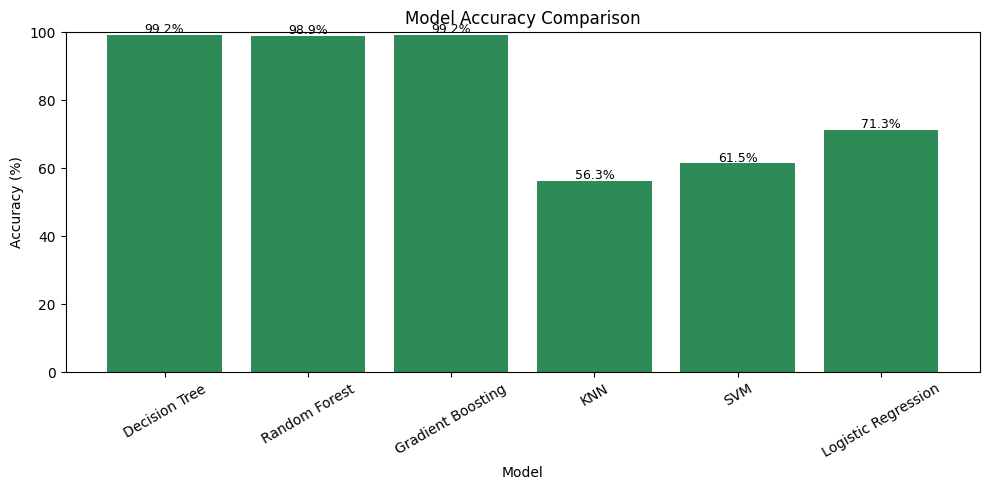

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), [v*100 for v in results.values()], color='seagreen')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=30)
plt.ylim(0, 100)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v*100 + 0.5, f"{v*100:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, best_model.predict(X_test),
      target_names=le_fertilizer.classes_))


🏆 Best Model: Decision Tree (99.19%)

Classification Report:
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       1.00      1.00      1.00        32
                   Compost       1.00      0.99      0.99        84
                       DAP       0.99      1.00      1.00       206
General Purpose Fertilizer       1.00      1.00      1.00         7
                    Gypsum       1.00      0.83      0.91         6
                      Lime       0.97      0.97      0.97        39
         Muriate of Potash       1.00      1.00      1.00        66
        Organic Fertilizer       1.00      0.94      0.97        18
                      Urea       1.00      1.00      1.00        34
Water Retaining Fertilizer       0.98      0.99      0.99       128

                  accuracy                           0.99       620
                 macro avg       0.99      0.97      0.98       620
              weighted avg       0.99      0.99     

In [ ]:
def recommend_fertilizer(temperature, moisture, rainfall, ph,
                          nitrogen, phosphorous, potassium, carbon,
                          soil_type, crop_type):

    soil_enc = le_soil.transform([soil_type])[0]
    crop_enc = le_crop.transform([crop_type])[0]

    input_data = pd.DataFrame([[temperature, moisture, rainfall, ph,
                                 nitrogen, phosphorous, potassium, carbon,
                                 soil_enc, crop_enc]],
                               columns=X.columns)

    prediction = best_model.predict(input_data)
    fertilizer = le_fertilizer.inverse_transform(prediction)[0]
    return fertilizer

# ✏️ Change these values to your farm's data
result = recommend_fertilizer(
    temperature=30,
    moisture=0.6,
    rainfall=100,
    ph=6.5,
    nitrogen=60,
    phosphorous=70,
    potassium=65,
    carbon=1.5,
    soil_type='Sandy',    # use exact name from your dataset
    crop_type='Wheat'     # use exact name from your dataset
)

print(f"\n🌱 Recommended Fertilizer: {result}")

ValueError: y contains previously unseen labels: 'Sandy'